# MPEC Evaluation for example_02a_elasticDemand_EE_Ramp

This notebook evaluates the bilevel MPEC formulation for the elastic demand scenario with
renewable energy (wind) and ramping constraints.

**Key characteristics:**
- No storage units
- 10 elastic demand bids (isoelastic demand model)
- Ramping constraints on conventional generators (500 MW/h)
- Wind onshore as renewable generation
- 7 generators total (2 nuclear, 1 lignite, 1 hard coal, 1 wind, 2 CCGT)

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils as utils
from sqlalchemy import create_engine

from assume import World
from assume.scenario.loader_csv import load_scenario_folder

c:\Users\tg3533\AppData\Local\miniconda3\envs\assume-framework\Lib\site-packages\pyomo\common\dependencies.py:471: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  self._loader.exec_module(module)


## 1. Scenario Parameters

In [2]:
if os.path.basename(os.getcwd()) == "MPEC":
    %cd ../../..

db_uri = "sqlite:///./examples/local_db/assume_db.db"
inputs_dir = "examples/inputs"
scenario = "example_02a_elasticDemand_EE_Ramp"
study_case = "base"

db = create_engine(db_uri)
print(f"Scenario: {scenario}, Study case: {study_case}")

c:\Users\tg3533\Documents\Code\assume
Scenario: example_02a_elasticDemand_EE_Ramp, Study case: base


## 2. Load Data from Simulation DB

In [3]:
study_case_config = utils.load_config(inputs_dir, scenario, study_case)
start = pd.Timestamp(study_case_config["start_date"])
end = pd.Timestamp(study_case_config["end_date"])

index = pd.date_range(
    start=start,
    end=end,
    freq=study_case_config["time_step"],
)

# NOTE: No demand_df.csv in this scenario — demand is purely isoelastic
# and defined only through market order bids (demand_units.csv specifies
# the elastic model parameters, the actual bid curves are in market_orders)
print(f"Time range: {start} to {end}")
print(f"Timesteps: {len(index)}")

Time range: 2019-03-01 00:00:00 to 2019-03-30 00:00:00
Timesteps: 697


In [4]:
pp_units = pd.read_csv(
    os.path.join(inputs_dir, scenario, "powerplant_units.csv"), index_col=0
)
pp_units.reset_index(inplace=True)
pp_units.rename(columns={"name": "unit"}, inplace=True)
pp_units

,unit,technology,bidding_EOM,fuel_type,emission_factor,max_power,min_power,efficiency,additional_cost,ramp_up,ramp_down,unit_operator
0,pp_1,nuclear,powerplant_energy_heuristic_flexable,uranium,0.000,1000,0,0.36,10.00,500,500,Operator 1
1,pp_2,nuclear,powerplant_energy_heuristic_flexable,uranium,0.000,1000,0,0.36,10.00,500,500,Operator 1
2,pp_3,lignite,powerplant_energy_heuristic_flexable,lignite,0.406,1000,0,0.41,2.00,500,500,Operator 1
3,pp_4,hard coal,powerplant_energy_heuristic_flexable,hard coal,0.335,1000,0,0.48,1.00,500,500,Operator 1
4,Wind Onshore,wind_onshore,powerplant_energy_heuristic_flexable,renewable,0.000,2500,0,1.00,0.01,2500,2500,Operator 1
5,pp_6,combined cycle gas turbine,powerplant_energy_heuristic_flexable,natural gas,0.201,2500,0,0.60,4.00,2500,2500,Operator 1
6,pp_7,combined cycle gas turbine,powerplant_energy_heuristic_flexable,natural gas,0.201,5000,0,0.60,34.00,5000,5000,Operator 1


### Verify: No storage units in this scenario

In [5]:
storage_path = os.path.join(inputs_dir, scenario, "storage_units.csv")
if os.path.exists(storage_path):
    print("WARNING: Storage units found — this notebook assumes no storage!")
    storage_units = pd.read_csv(storage_path, index_col=0)
    display(storage_units)
else:
    print("Confirmed: No storage units in this scenario.")

Confirmed: No storage units in this scenario.


### Load dispatch and market orders from DB

In [6]:
sim_id = f"{scenario}_{study_case}"

query = f"SELECT * FROM unit_dispatch WHERE simulation = '{sim_id}'"
dispatch_df = pd.read_sql(query, db)
dispatch_df = dispatch_df.sort_values("time")
dispatch_df.index = pd.to_datetime(dispatch_df["time"])
dispatch_df.drop(columns=["time"], inplace=True)
dispatch_df["date"] = dispatch_df.index.date

print(f"Dispatch rows: {len(dispatch_df)}")
print(f"Units: {dispatch_df['unit'].unique().tolist()}")
dispatch_df.head()

Dispatch rows: 5568
Units: ['demand_EOM', 'pp_1', 'pp_7', 'pp_2', 'pp_3', 'pp_6', 'pp_4', 'Wind Onshore']


,energy_cashflow,energy_generation_costs,heat,power,simulation,soc,total_costs,unit,date
time,,,,,,,,,
2019-03-01,NaN,0.0,NaN,0.0,example_02a_elasticDemand_EE_Ramp_base,None,NaN,demand_EOM,2019-03-01
2019-03-01,NaN,0.0,0.0,0.0,example_02a_elasticDemand_EE_Ramp_base,None,NaN,pp_1,2019-03-01
2019-03-01,NaN,0.0,0.0,0.0,example_02a_elasticDemand_EE_Ramp_base,None,NaN,pp_7,2019-03-01
2019-03-01,NaN,0.0,0.0,0.0,example_02a_elasticDemand_EE_Ramp_base,None,NaN,pp_2,2019-03-01
2019-03-01,NaN,0.0,0.0,0.0,example_02a_elasticDemand_EE_Ramp_base,None,NaN,pp_3,2019-03-01


In [7]:
query = f"SELECT * FROM market_orders WHERE simulation = '{sim_id}'"
market_orders_df = pd.read_sql(query, db)
market_orders_df["time"] = pd.to_datetime(market_orders_df["start_time"])

print(f"Market order rows: {len(market_orders_df)}")
print(f"Unique unit_ids: {market_orders_df['unit_id'].unique().tolist()}")

# Show demand bid structure
demand_bids = market_orders_df[market_orders_df["unit_id"] == "demand_EOM"]
print(f"Demand bid_ids: {sorted(demand_bids['bid_id'].unique().tolist())}")
print(f"Number of demand bids per timestep: {demand_bids['bid_id'].nunique()}")

Market order rows: 11815
Unique unit_ids: ['pp_1', 'pp_2', 'pp_3', 'pp_4', 'Wind Onshore', 'pp_6', 'pp_7', 'demand_EOM']
Demand bid_ids: ['demand_EOM_1', 'demand_EOM_10', 'demand_EOM_2', 'demand_EOM_3', 'demand_EOM_4', 'demand_EOM_5', 'demand_EOM_6', 'demand_EOM_7', 'demand_EOM_8', 'demand_EOM_9']
Number of demand bids per timestep: 10


### Get marginal costs from World object

In [8]:
world = World(database_uri=db_uri)
load_scenario_folder(world, inputs_dir, scenario, study_case)

INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: examples/inputs/example_02a_elasticDemand_EE_Ramp
INFO:assume.scenario.loader_csv:Study case: base
INFO:assume.scenario.loader_csv:Simulation ID: example_02a_elasticDemand_EE_Ramp_base
INFO:assume.scenario.loader_csv:examples\inputs\example_02a_elasticDemand_EE_Ramp\unit_operators.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02a_elasticDemand_EE_Ramp\storage_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02a_elasticDemand_EE_Ramp\exchange_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02a_elasticDemand_EE_Ramp\industrial_dsm_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:examples\inputs\example_02a_elasticDemand_EE_Ramp\residential_dsm_units.csv not found. Returning None
INFO:assume.common.utils:Downsampling examples\inputs\example_02a_elasticD

In [9]:
marginal_costs_df = utils.extract_marginal_costs(
    world, "Operator 1", index
)
print("Marginal costs per unit:")
for col in marginal_costs_df.columns:
    print(f"  {col}: {marginal_costs_df[col].iloc[0]:.4f} EUR/MWh")
marginal_costs_df.head()

Marginal costs per unit:
  pp_1: 12.5000 EUR/MWh
  pp_2: 12.5000 EUR/MWh
  pp_3: 31.1463 EUR/MWh
  pp_4: 36.1562 EUR/MWh
  Wind Onshore: 0.0100 EUR/MWh
  pp_6: 55.7083 EUR/MWh
  pp_7: 85.7083 EUR/MWh


,pp_1,pp_2,pp_3,pp_4,Wind Onshore,pp_6,pp_7
2019-03-01 00:00:00,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
2019-03-01 01:00:00,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
2019-03-01 02:00:00,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
2019-03-01 03:00:00,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
2019-03-01 04:00:00,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333


In [10]:
# Merge marginal costs into dispatch_df
mc_long = marginal_costs_df.reset_index().melt(
    id_vars="index", var_name="unit", value_name="marginal_cost"
)
mc_long = mc_long.rename(columns={"index": "time"})
dispatch_df = dispatch_df.merge(mc_long, on=["time", "unit"], how="left")

## 3. Visualise Merit Order and Dispatch

In [11]:
gens_df = utils.create_gens_df(pp_units, dispatch_df)
print("Generator DataFrame with ramp constraints:")
print(gens_df[["unit", "g_max", "u_0", "mc", "r_up", "r_down"]].to_string(index=False))

Generator DataFrame with ramp constraints:
        unit  g_max  u_0        mc  r_up  r_down
        pp_1   1000    0 12.500000   500     500
        pp_2   1000    0 12.500000   500     500
        pp_3   1000    0 31.146341   500     500
        pp_4   1000    0 36.156250   500     500
Wind Onshore   2500    0  0.010000  2500    2500
        pp_6   2500    0 55.708333  2500    2500
        pp_7   5000    0 85.708333  5000    5000


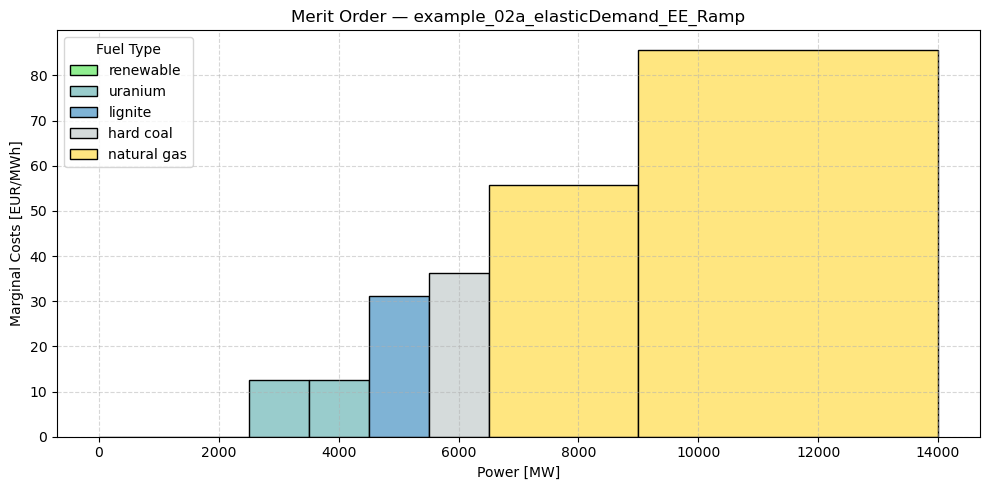

In [12]:
# Merit order plot
gens_sorted = gens_df.sort_values("mc").reset_index(drop=True)

color_map = {
    "uranium": "#99cccc",
    "lignite": "#7fb3d5",
    "hard coal": "#d5dbdb",
    "natural gas": "#ffe680",
    "renewable": "#90ee90",
}

left_edges = np.concatenate([[0], gens_sorted["g_max"].cumsum()[:-1]])

plt.figure(figsize=(10, 5))
labels_seen = []
for i, row in gens_sorted.iterrows():
    fuel = row["fuel_type"]
    color = color_map.get(fuel, "#cccccc")
    plt.bar(
        left_edges[i], row["mc"], width=row["g_max"], align="edge",
        color=color, edgecolor="black",
        label=fuel if fuel not in labels_seen else "",
    )
    labels_seen.append(fuel)

plt.legend(title="Fuel Type")
plt.xlabel("Power [MW]")
plt.ylabel("Marginal Costs [EUR/MWh]")
plt.title("Merit Order — example_02a_elasticDemand_EE_Ramp")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Build MPEC Input Data

Transform simulation data into the format expected by the MPEC solver.
Since there is no `demand_df.csv` (demand is purely isoelastic), the demand
curve is reconstructed from market order bids (10 price/volume pairs per timestep).

Export ALL data — date selection happens in `solve_all_learning_units_02a.py`.

In [13]:
# Set market orders index to start_time
market_orders_df.index = pd.to_datetime(market_orders_df["start_time"])
market_orders_df = market_orders_df.drop(columns=["start_time"], errors="ignore")
market_orders_df["date"] = market_orders_df.index.date

# Use all dates from market orders (no demand_df.csv in this scenario)
unique_dates = sorted(market_orders_df.index.normalize().unique())
print(f"Exporting all {len(unique_dates)} unique dates")
print(f"Date range: {unique_dates[0].date()} to {unique_dates[-1].date()}")

Exporting all 29 unique dates
Date range: 2019-03-01 to 2019-03-29


In [14]:
# Build demand_df with multiple bid columns directly from market orders
# (no demand_df.csv exists — demand is purely isoelastic with 10 bids)
# In the multi-bid path, join_demand_market_orders builds the output
# entirely from market_orders, so we pass a dummy demand_df.
dummy_demand_df = pd.DataFrame(index=market_orders_df.index.unique().sort_values())
demand_mpec = utils.join_demand_market_orders(dummy_demand_df, market_orders_df)
print(f"Demand MPEC shape: {demand_mpec.shape}")
print(f"Columns: {demand_mpec.columns.tolist()}")
demand_mpec.head()

Demand MPEC shape: (695, 21)
Columns: ['price_1', 'volume_1', 'price_2', 'volume_2', 'price_3', 'volume_3', 'price_4', 'volume_4', 'price_5', 'volume_5', 'price_6', 'volume_6', 'price_7', 'volume_7', 'price_8', 'volume_8', 'price_9', 'volume_9', 'price_10', 'volume_10', 'date']


,price_1,volume_1,price_2,volume_2,price_3,volume_3,price_4,volume_4,price_5,volume_5,...,volume_6,price_7,volume_7,price_8,volume_8,price_9,volume_9,price_10,volume_10,date
datetime,,,,,,,,,,,,,,,,,,,,,
2019-03-01 01:00:00,3000.0,6224.105515,1089.655571,231.766054,410.177716,231.766054,159.629204,231.766054,64.085131,231.766054,...,231.766054,11.251087,231.766054,4.903359,231.766054,2.189241,231.766054,1.0,231.766054,2019-03-01
2019-03-01 02:00:00,3000.0,6224.105515,1089.655571,231.766054,410.177716,231.766054,159.629204,231.766054,64.085131,231.766054,...,231.766054,11.251087,231.766054,4.903359,231.766054,2.189241,231.766054,1.0,231.766054,2019-03-01
2019-03-01 03:00:00,3000.0,6224.105515,1089.655571,231.766054,410.177716,231.766054,159.629204,231.766054,64.085131,231.766054,...,231.766054,11.251087,231.766054,4.903359,231.766054,2.189241,231.766054,1.0,231.766054,2019-03-01
2019-03-01 04:00:00,3000.0,6224.105515,1089.655571,231.766054,410.177716,231.766054,159.629204,231.766054,64.085131,231.766054,...,231.766054,11.251087,231.766054,4.903359,231.766054,2.189241,231.766054,1.0,231.766054,2019-03-01
2019-03-01 05:00:00,3000.0,6224.105515,1089.655571,231.766054,410.177716,231.766054,159.629204,231.766054,64.085131,231.766054,...,231.766054,11.251087,231.766054,4.903359,231.766054,2.189241,231.766054,1.0,231.766054,2019-03-01


In [15]:
# Build k_values from market orders (price / marginal_cost)
merged_df = market_orders_df.merge(
    dispatch_df[["unit", "time", "marginal_cost"]].reset_index(drop=True),
    left_on=["unit_id", "time"],
    right_on=["unit", "time"],
    how="left",
)

k_df = merged_df[["unit_id", "time", "price", "marginal_cost"]].copy()
k_values_df = utils.obtain_k_values(k_df, gens_df)
print(f"k_values shape: {k_values_df.shape}")
k_values_df.head()

k_values shape: (695, 8)


unit_id,pp_1,pp_2,pp_3,pp_4,Wind Onshore,pp_6,pp_7,date
time,,,,,,,,
2019-03-01 01:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 02:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 03:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 04:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 05:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01


In [16]:
# Build availability_df
raw_avail = utils.load_availabilities(inputs_dir, scenario)
unit_names = gens_df["unit"].tolist()
availability_df = utils.build_availability_df(raw_avail, k_values_df.index, unit_names)

print(f"Availability shape: {availability_df.shape}")
print("Sample availability (Wind Onshore):")
if "Wind Onshore" in availability_df.columns:
    print(f"  min={availability_df['Wind Onshore'].min():.3f}, max={availability_df['Wind Onshore'].max():.3f}")
availability_df.head()

Resampled availability_df to hourly using mean().
Availability shape: (695, 7)
Sample availability (Wind Onshore):
  min=0.009, max=0.748


,pp_1,pp_2,pp_3,pp_4,Wind Onshore,pp_6,pp_7
time,,,,,,,
2019-03-01 01:00:00,1.0,1.0,1.0,1.0,0.162587,1.0,1.0
2019-03-01 02:00:00,1.0,1.0,1.0,1.0,0.152571,1.0,1.0
2019-03-01 03:00:00,1.0,1.0,1.0,1.0,0.145521,1.0,1.0
2019-03-01 04:00:00,1.0,1.0,1.0,1.0,0.139039,1.0,1.0
2019-03-01 05:00:00,1.0,1.0,1.0,1.0,0.132680,1.0,1.0


In [17]:
# Build mc_df (marginal costs aligned to k_values index)
gens_df_idx = gens_df.set_index("unit") if "unit" in gens_df.columns else gens_df.copy()
mc_df = pd.DataFrame(
    {gen: gens_df_idx.at[gen, "mc"] for gen in gens_df_idx.index},
    index=range(len(k_values_df)),
)
mc_df.head()

,pp_1,pp_2,pp_3,pp_4,Wind Onshore,pp_6,pp_7
0,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
1,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
2,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
3,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333
4,12.5,12.5,31.146341,36.15625,0.01,55.708333,85.708333


In [18]:
# Export to mpec_input_data_02a/
out_dir = os.path.join("examples", "notebooks", "MPEC", "mpec_input_data_02a")
os.makedirs(out_dir, exist_ok=True)

gens_df.to_csv(os.path.join(out_dir, "gens_df.csv"))
demand_mpec.to_csv(os.path.join(out_dir, "demand_df.csv"))
k_values_df.to_csv(os.path.join(out_dir, "k_values_df.csv"))
availability_df.to_csv(os.path.join(out_dir, "availability_df.csv"))
dispatch_df.to_csv(os.path.join(out_dir, "dispatch_df.csv"))

print(f"Exported to {out_dir}/")
for f in os.listdir(out_dir):
    size = os.path.getsize(os.path.join(out_dir, f)) / 1024
    print(f"  {f}: {size:.1f} KB")

Exported to examples\notebooks\MPEC\mpec_input_data_02a/
  availability_df.csv: 43.7 KB
  availability_df.csv.license: 0.1 KB
  demand_df.csv: 244.5 KB
  demand_df.csv.license: 0.1 KB
  dispatch_df.csv: 818.6 KB
  dispatch_df.csv.license: 0.1 KB
  gens_df.csv: 1.1 KB
  gens_df.csv.license: 0.1 KB
  k_values_df.csv: 40.8 KB
  k_values_df.csv.license: 0.1 KB


## 5. Test MPEC for a Single Unit

Quick test: run MPEC + UC re-solve for one unit on a single day to verify the setup works.

In [19]:
mpec_dir = os.path.join(os.getcwd(), "examples", "notebooks", "MPEC")
if mpec_dir not in sys.path:
    sys.path.insert(0, mpec_dir)

from bilevel_opt import find_optimal_dispatch_quadratic_fixed_storage
from uc_problem import solve_uc_problem

In [20]:
# Select a single day and unit for testing
test_date = "2019-03-16"
test_start = pd.to_datetime(f"{test_date} 00:00")
test_end = pd.to_datetime(f"{test_date} 23:00")
test_idx = pd.date_range(test_start, test_end, freq="h")

opt_gen = "pp_6"  # first CCGT unit
mc_val = gens_df_idx.at[opt_gen, "mc"]
k_max = max(int(3100 / mc_val), 10) if mc_val > 0 else 300000
print(f"Testing: {opt_gen} (mc={mc_val:.4f}, k_max={k_max})")
print(f"Date: {test_date}, hours: {len(test_idx)}")

# Number of demand bids
demand_bid_cols = [c for c in demand_mpec.columns if c.startswith("volume_")]
n_demand_bids = len(demand_bid_cols)
print(f"Demand bids: {n_demand_bids}")

Testing: pp_6 (mc=55.7083, k_max=55)
Date: 2019-03-16, hours: 24
Demand bids: 10


In [21]:
# Prepare input dataframes for the test day
demand_test = demand_mpec.loc[test_idx].reset_index(drop=True).copy()
demand_test = demand_test.drop(columns=["date"], errors="ignore")

k_values_test = k_values_df.loc[test_idx].reset_index(drop=True).copy()
avail_test = availability_df.loc[test_idx].reset_index(drop=True).copy()

# Filter to generator columns only
gen_names = list(gens_df_idx.index)
k_values_test = k_values_test[[c for c in k_values_test.columns if c in gen_names]]
avail_test = avail_test[[c for c in avail_test.columns if c in gen_names]]

mc_test = pd.DataFrame(
    {gen: gens_df_idx.at[gen, "mc"] for gen in gen_names},
    index=demand_test.index,
)

# Make demand volumes positive
for col in demand_test.columns:
    if col.startswith("volume_"):
        demand_test[col] = demand_test[col].abs().clip(lower=0.01)

print(f"Demand range: {demand_test['volume_1'].min():.0f} to {demand_test['volume_1'].max():.0f} MW")
print(f"Ramp constraints: {gens_df_idx.loc[gen_names, 'r_up'].to_dict()}")

Demand range: 6224 to 6224 MW
Ramp constraints: {'pp_1': 500, 'pp_2': 500, 'pp_3': 500, 'pp_4': 500, 'Wind Onshore': 2500, 'pp_6': 2500, 'pp_7': 5000}


In [22]:
from bilevel_opt import find_optimal_dispatch_quadratic

# Run MPEC
t0 = time.time()
main_df, supp_df, k_vals = find_optimal_dispatch_quadratic(
    gens_df=gens_df_idx,
    k_values_df=k_values_test,
    availabilities_df=avail_test,
    demand_df=demand_test,
    k_max=k_max,
    opt_gen=opt_gen,
    big_w=100,
    time_limit=100,
    big_M=10e6,
    demand_bids=n_demand_bids,
    mc_df=mc_test,
)
t_mpec = time.time() - t0

if main_df is None:
    print(f"MPEC INFEASIBLE ({t_mpec:.1f}s)")
else:
    print(f"MPEC solved in {t_mpec:.1f}s")
    print(f"  lambda_: {main_df['mcp'].astype(float).min():.1f} to {main_df['mcp'].astype(float).max():.1f}")
    print(f"  lambda_hat: {main_df['mcp_hat'].astype(float).min():.1f} to {main_df['mcp_hat'].astype(float).max():.1f}")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-07-30
Read LP format model from file C:\Users\tg3533\AppData\Local\Temp\tmphv48j0k8.pyomo.lp
Reading time = 0.04 seconds
x1: 4800 rows, 4200 columns, 12290 nonzeros
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 100
Set parameter MIPGap to value 1
Set parameter DualReductions to value 0
Set parameter MIPFocus to value 2
Set parameter Heuristics to value 0.2
Set parameter Presolve to value 2
Set parameter Cuts to value 2
Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads
Optimize a model with 4800 rows, 4200 columns and 12290 nonzeros
Model fingerprint: 0xea5216ac
Model has 24 quadratic objective terms
Variable types: 3048 continuous, 1152 integer (1152 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+07]
  Objective range  [1e+00, 6e+05]
  QObjective range [2e+00, 2e+00]
  Bounds range   

In [23]:
# UC re-solve with MPEC k-values
if main_df is not None:
    k_values_uc = k_values_test.copy()
    k_series = pd.to_numeric(k_vals["k"], errors="coerce")
    fallback = pd.to_numeric(k_values_uc[opt_gen], errors="coerce").fillna(1.0)
    k_values_uc[opt_gen] = k_series.fillna(fallback).astype(float).values
    for col in k_values_uc.columns:
        k_values_uc[col] = pd.to_numeric(k_values_uc[col], errors="coerce").fillna(1.0)

    t0 = time.time()
    uc_main, uc_supp = solve_uc_problem(
        gens_df=gens_df_idx,
        demand_df=demand_test,
        k_values_df=k_values_uc,
        availabilities_df=avail_test,
        demand_bids=n_demand_bids,
        mc_df=mc_test,
        fixed_storage_dispatch=None,
    )
    t_uc = time.time() - t0
    print(f"UC solved in {t_uc:.1f}s")
    print(f"  UC MCP: {uc_main['mcp'].astype(float).min():.1f} to {uc_main['mcp'].astype(float).max():.1f}")

UC solved in 1.2s
  UC MCP: 85.7 to 85.7


In [24]:
# UC baseline (no strategic bidding)

uc_base_main, _ = solve_uc_problem(
    gens_df=gens_df_idx,
    demand_df=demand_test,
    k_values_df=k_values_test,
    availabilities_df=avail_test,
    demand_bids=n_demand_bids,
    mc_df=mc_test,
    fixed_storage_dispatch=None,
)
print(f"  Baseline UC MCP: {uc_base_main['mcp'].astype(float).min():.1f} to {uc_base_main['mcp'].astype(float).max():.1f}")

  Baseline UC MCP: 55.7 to 85.7


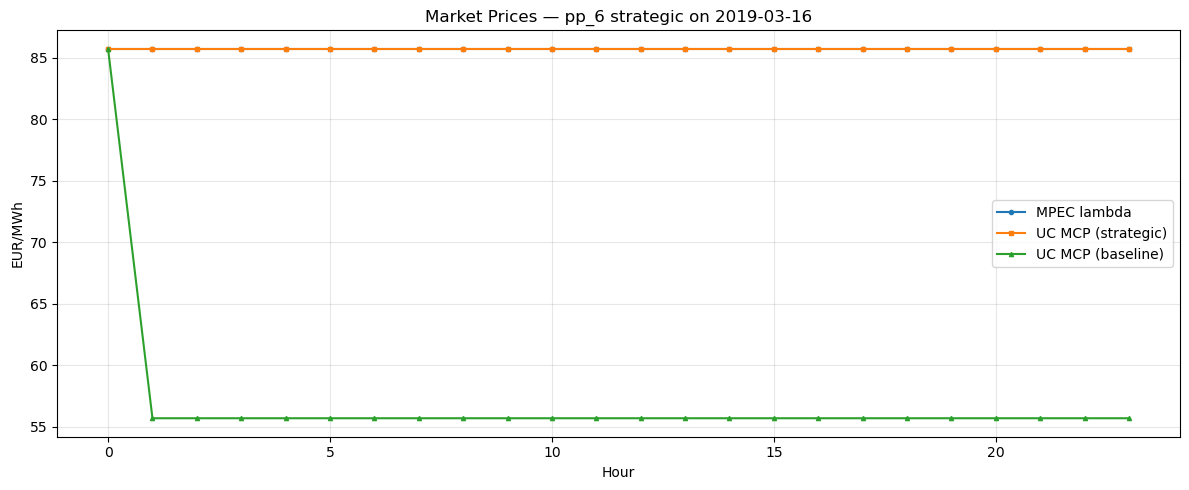

In [25]:
# Plot comparison

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(main_df["mcp"].astype(float).values, label="MPEC lambda", marker="o", ms=3)
ax.plot(uc_main["mcp"].astype(float).values, label="UC MCP (strategic)", marker="s", ms=3)
ax.plot(uc_base_main["mcp"].astype(float).values, label="UC MCP (baseline)", marker="^", ms=3)
ax.set_xlabel("Hour")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Market Prices — {opt_gen} strategic on {test_date}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Demand Curve Visualisation

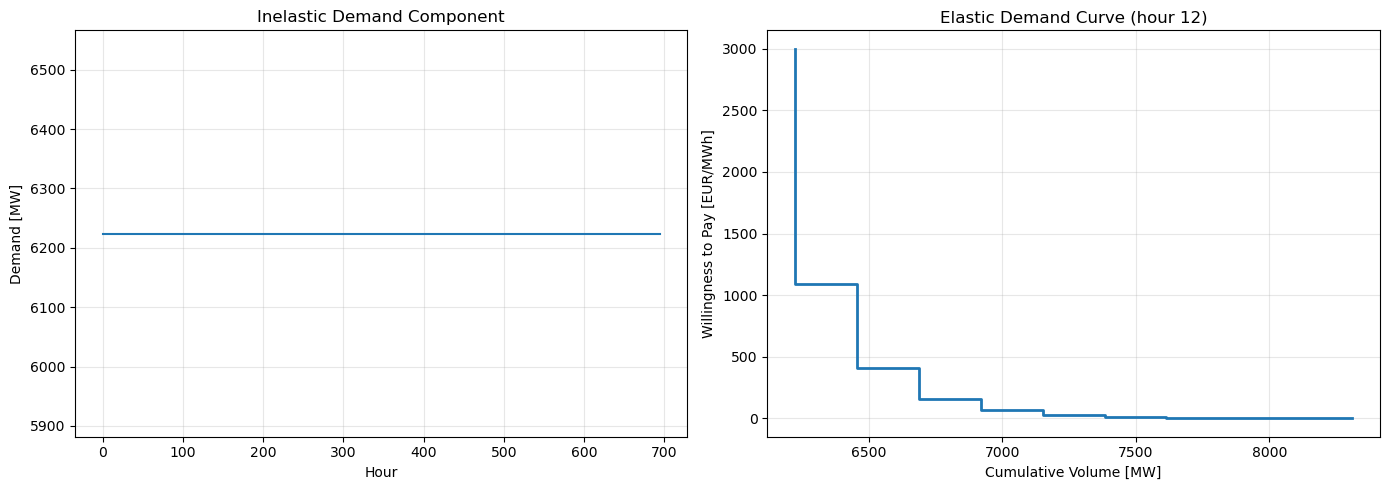

In [26]:
# Plot the elastic demand curve for a single timestep
n_demand_bids = len([c for c in demand_mpec.columns if c.startswith("volume_")])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: demand volumes over time (first bid only)
ax = axes[0]
ax.plot(demand_mpec["volume_1"].abs().values, label="volume_1 (inelastic)")
ax.set_xlabel("Hour")
ax.set_ylabel("Demand [MW]")
ax.set_title("Inelastic Demand Component")
ax.grid(True, alpha=0.3)

# Right: demand curve (all bids) for one timestep
ax = axes[1]
t = 12  # pick a mid-day hour
row = demand_mpec.iloc[t]
volumes = []
prices = []
for i in range(1, n_demand_bids + 1):
    v = abs(row.get(f"volume_{i}", 0))
    p = row.get(f"price_{i}", 0)
    if v > 0:
        volumes.append(v)
        prices.append(p)

cum_vol = np.cumsum(volumes)
ax.step(cum_vol, prices, where="pre", linewidth=2)
ax.set_xlabel("Cumulative Volume [MW]")
ax.set_ylabel("Willingness to Pay [EUR/MWh]")
ax.set_title(f"Elastic Demand Curve (hour {t})")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

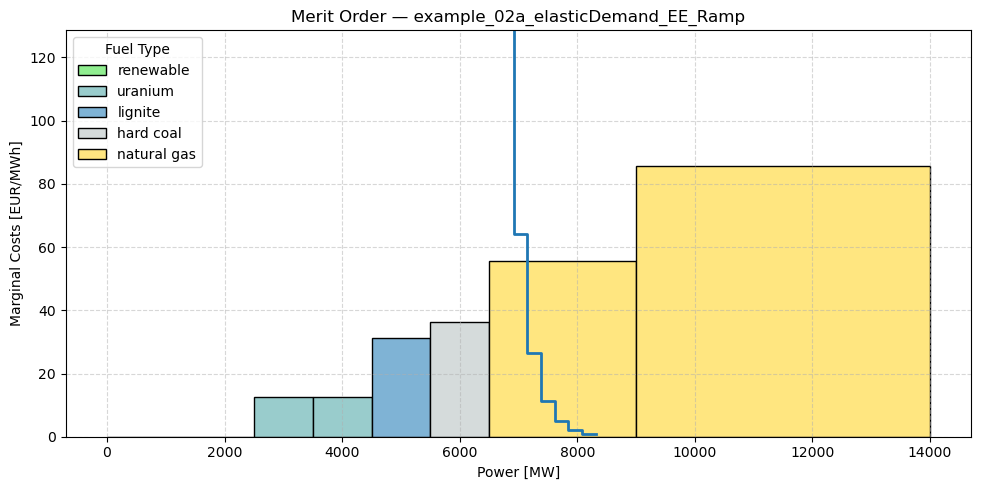

In [27]:
# Merit order plot
gens_sorted = gens_df.sort_values("mc").reset_index(drop=True)

color_map = {
    "uranium": "#99cccc",
    "lignite": "#7fb3d5",
    "hard coal": "#d5dbdb",
    "natural gas": "#ffe680",
    "renewable": "#90ee90",
}

left_edges = np.concatenate([[0], gens_sorted["g_max"].cumsum()[:-1]])

plt.figure(figsize=(10, 5))
labels_seen = []
for i, row in gens_sorted.iterrows():
    fuel = row["fuel_type"]
    color = color_map.get(fuel, "#cccccc")
    plt.bar(
        left_edges[i], row["mc"], width=row["g_max"], align="edge",
        color=color, edgecolor="black",
        label=fuel if fuel not in labels_seen else "",
    )
    labels_seen.append(fuel)

plt.step(cum_vol, prices, where="pre", linewidth=2)

plt.legend(title="Fuel Type")
plt.xlabel("Power [MW]")
plt.ylabel("Marginal Costs [EUR/MWh]")
plt.title("Merit Order — example_02a_elasticDemand_EE_Ramp")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0, max(gens_sorted["mc"]) * 1.5)
plt.show()

## 7. Run MPEC for All Units

For the full batch solve across all units and dates, use:
```bash
python solve_all_learning_units_02a.py
```

Below is a loop over all generators for the test day.

In [28]:
from bilevel_opt import find_optimal_dispatch_quadratic

# Run MPEC + UC for all non-renewable generators on the test day
res_lambda = {}
res_lambda_hat = {}
res_uc_mcp = {}
res_k_vals = {}
res_main_df = {}

for opt_gen in gen_names:
    mc_val = gens_df_idx.at[opt_gen, "mc"]


    k_max = max(int(300 / mc_val), 10)
    print(f"\n--- {opt_gen} (mc={mc_val:.4f}, k_max={k_max}) ---")

    t0 = time.time()
    main_df, supp_df, k_vals = find_optimal_dispatch_quadratic(
        gens_df=gens_df_idx,
        k_values_df=k_values_test,
        availabilities_df=avail_test,
        demand_df=demand_test,
        k_max=k_max,
        opt_gen=opt_gen,
        big_w=100,
        time_limit=100,
        big_M=10e6,
        demand_bids=n_demand_bids,
        mc_df=mc_test,
        )
    t_mpec = time.time() - t0

    if main_df is None:
        print(f"  INFEASIBLE ({t_mpec:.1f}s)")
        continue

    res_lambda[opt_gen] = main_df["mcp"].astype(float)
    res_lambda_hat[opt_gen] = main_df["mcp_hat"].astype(float)
    res_k_vals[opt_gen] = k_vals["k"].astype(float)
    res_main_df[opt_gen] = main_df

    # UC re-solve
    k_values_uc = k_values_test.copy()
    k_series = pd.to_numeric(k_vals["k"], errors="coerce")
    fallback = pd.to_numeric(k_values_uc[opt_gen], errors="coerce").fillna(1.0)
    k_values_uc[opt_gen] = k_series.fillna(fallback).astype(float).values
    for col in k_values_uc.columns:
        k_values_uc[col] = pd.to_numeric(k_values_uc[col], errors="coerce").fillna(1.0)

    uc_main, _ = solve_uc_problem(
        gens_df=gens_df_idx,
        demand_df=demand_test,
        k_values_df=k_values_uc,
        availabilities_df=avail_test,
        demand_bids=n_demand_bids,
        mc_df=mc_test,
        fixed_storage_dispatch=None,
    )
    res_uc_mcp[opt_gen] = uc_main["mcp"].astype(float)
    print(f"  OK ({t_mpec:.1f}s) | k={res_k_vals[opt_gen].mean():.2f} | lambda: {res_lambda[opt_gen].min():.1f}–{res_lambda[opt_gen].max():.1f} | UC: {res_uc_mcp[opt_gen].min():.1f}–{res_uc_mcp[opt_gen].max():.1f}")


--- pp_1 (mc=12.5000, k_max=24) ---
Set parameter Username
Academic license - for non-commercial use only - expires 2026-07-30
Read LP format model from file C:\Users\tg3533\AppData\Local\Temp\tmpmblpqang.pyomo.lp
Reading time = 0.03 seconds
x1: 4800 rows, 4200 columns, 12290 nonzeros
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 100
Set parameter MIPGap to value 1
Set parameter DualReductions to value 0
Set parameter MIPFocus to value 2
Set parameter Heuristics to value 0.2
Set parameter Presolve to value 2
Set parameter Cuts to value 2
Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads
Optimize a model with 4800 rows, 4200 columns and 12290 nonzeros
Model fingerprint: 0xe3aae75e
Model has 24 quadratic objective terms
Variable types: 3048 continuous, 1152 integer (1152 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+07]
  Objective range  [1e+00, 6e+05]
  QObjective r

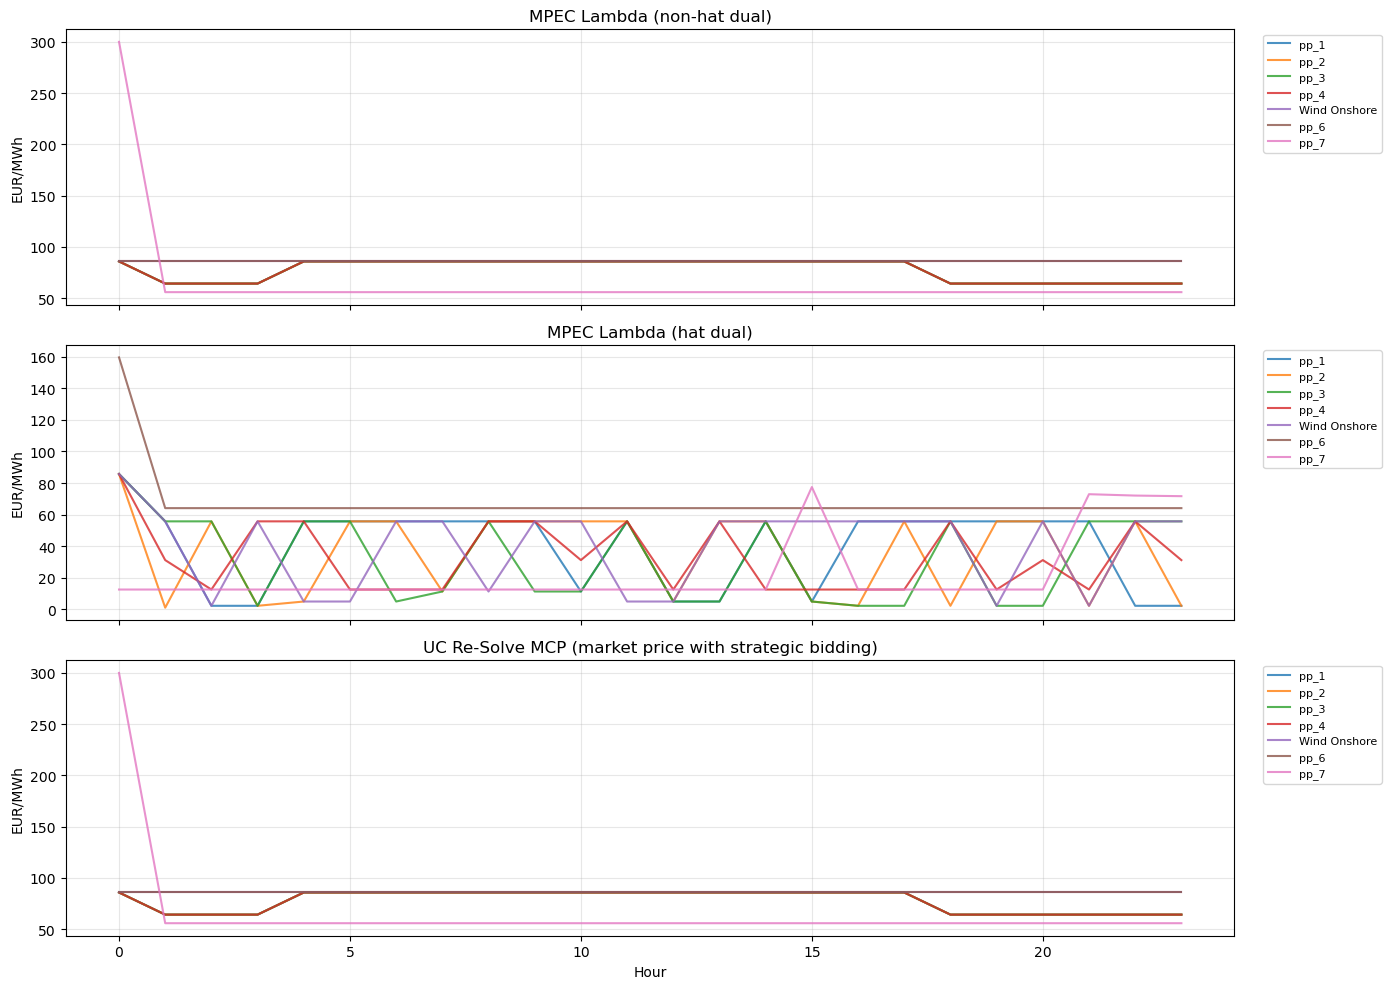

In [29]:
# Summary plot: all units
if res_uc_mcp:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    for unit, series in res_lambda.items():
        ax.plot(series.values, label=unit, alpha=0.8)
    ax.set_ylabel("EUR/MWh")
    ax.set_title("MPEC Lambda (non-hat dual)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    for unit, series in res_lambda_hat.items():
        ax.plot(series.values, label=unit, alpha=0.8)
    ax.set_ylabel("EUR/MWh")
    ax.set_title("MPEC Lambda (hat dual)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    for unit, series in res_uc_mcp.items():
        ax.plot(series.values, label=unit, alpha=0.8)
    ax.set_ylabel("EUR/MWh")
    ax.set_xlabel("Hour")
    ax.set_title("UC Re-Solve MCP (market price with strategic bidding)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

## 8. Interactive Merit Order with Strategic Bidding

Interactive plot per optimised unit showing:
- **Supply curve** (merit order) with wind at available capacity
- **Bid price** of the strategic unit (`k * mc`) instead of marginal cost
- **Cleared market price** (UC MCP) as horizontal line
- **Demand curve** as step function

In [ ]:
from ipywidgets import interact, IntSlider, Dropdown

color_map_unit = {
    "pp_1": "#99cccc",
    "pp_2": "#88bbbb",
    "pp_3": "#7fb3d5",
    "pp_4": "#d5dbdb",
    "Wind Onshore": "#90ee90",
    "pp_6": "#ffe680",
    "pp_7": "#ffcc33",
}

def plot_merit_order(hour=0, strategic_unit="pp_6"):
    if strategic_unit not in res_k_vals:
        print(f"No MPEC result for {strategic_unit}")
        return

    k_opt = float(res_k_vals[strategic_unit].iloc[hour])
    mcp_uc = float(res_uc_mcp[strategic_unit].iloc[hour])
    mcp_hat = float(res_lambda_hat[strategic_unit].iloc[hour])

    # Build supply blocks: (unit, capacity, bid_price)
    supply = []
    for unit in gen_names:
        mc_val = gens_df_idx.at[unit, "mc"]
        g_max = gens_df_idx.at[unit, "g_max"]

        # Wind: use availability-adjusted capacity
        if unit == "Wind Onshore":
            cap = g_max * float(avail_test.at[hour, unit])
        else:
            cap = g_max

        # Strategic unit bids at k * mc
        if unit == strategic_unit:
            bid_price = k_opt * mc_val
        else:
            bid_price = mc_val

        supply.append((unit, cap, bid_price, mc_val))

    # Sort by bid price (merit order)
    supply.sort(key=lambda x: x[2])

    # Build demand curve
    demand_prices = []
    demand_cum_vols = []
    cum = 0
    for i in range(1, n_demand_bids + 1):
        p = float(demand_test.at[hour, f"price_{i}"])
        v = float(demand_test.at[hour, f"volume_{i}"])
        demand_prices.append(p)
        cum += v
        demand_cum_vols.append(cum)

    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot supply blocks
    x_pos = 0
    for unit, cap, bid_price, mc_val in supply:
        color = color_map_unit.get(unit, "#cccccc")
        edgecolor = "red" if unit == strategic_unit else "black"
        linewidth = 2.5 if unit == strategic_unit else 1.0

        bar = ax.bar(
            x_pos, bid_price, width=cap, align="edge",
            color=color, edgecolor=edgecolor, linewidth=linewidth,
            label=unit, zorder=2,
        )

        # Label inside bar
        label_x = x_pos + cap / 2
        label_y = bid_price / 2 if bid_price > 15 else bid_price + 3
        if unit == strategic_unit:
            label_text = f"{unit}\nk={k_opt:.2f}\nbid={bid_price:.1f}"
        elif unit == "Wind Onshore":
            label_text = f"Wind\n{cap:.0f} MW"
        else:
            label_text = f"{unit}\n{mc_val:.1f}"
        ax.text(label_x, label_y, label_text, ha="center", va="center", fontsize=7, zorder=3)

        x_pos += cap

    # Demand curve (step function, right side)
    demand_x = [0] + list(demand_cum_vols)
    demand_y = [demand_prices[0]] + list(demand_prices)
    ax.step(demand_x, demand_y, where="post", color="darkblue", linewidth=2, linestyle="--", label="Demand", zorder=4)

    # MCP lines
    ax.axhline(y=mcp_uc, color="red", linewidth=2, linestyle="-", label=f"UC MCP = {mcp_uc:.1f}", zorder=5)
    ax.axhline(y=mcp_hat, color="orange", linewidth=1.5, linestyle=":", label=f"λ_hat = {mcp_hat:.1f}", zorder=5)

    # Formatting
    max_price_show = max(mcp_hat * 1.5, max(s[2] for s in supply) * 1.2, 120)
    ax.set_ylim(0, min(max_price_show, 350))
    ax.set_xlim(0, x_pos * 1.05)
    ax.set_xlabel("Cumulative Capacity [MW]", fontsize=12)
    ax.set_ylabel("Price [EUR/MWh]", fontsize=12)
    ax.set_title(
        f"Merit Order — {strategic_unit} strategic (k={k_opt:.2f}) — Hour {hour}:00 — {test_date}",
        fontsize=13,
    )
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()


interact(
    plot_merit_order,
    hour=IntSlider(min=0, max=23, step=1, value=12, description="Hour:"),
    strategic_unit=Dropdown(
        options=[u for u in gen_names if u in res_k_vals],
        value="pp_6" if "pp_6" in res_k_vals else list(res_k_vals.keys())[0],
        description="Unit:",
    ),
)

interactive(children=(IntSlider(value=12, description='Hour:', max=23), Dropdown(description='Unit:', index=5,…

<function __main__.plot_merit_order(hour=0, strategic_unit='pp_6')>